In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

In [ ]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from engine.noise import fbm, perlin
from engine.heightmap import normalize

In [ ]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

terrain = config["terrain"]
noise_cfg = config["noise"]
render_cfg = config.get("render", {})

In [ ]:
noise_type = noise_cfg["type"]

if noise_type == "perlin":
    hm = perlin(
        terrain["width"],
        terrain["height"],
        scale=noise_cfg["scale"],
        seed=noise_cfg.get("seed")
    )

elif noise_type == "fbm":
    hm = fbm(
        terrain["width"],
        terrain["height"],
        scale=noise_cfg["scale"],
        octaves=noise_cfg.get("octaves", 4),
        seed=noise_cfg.get("seed")
    )

else:
    raise ValueError(f"Unknown noise type: {noise_type}")

hm = normalize(hm)

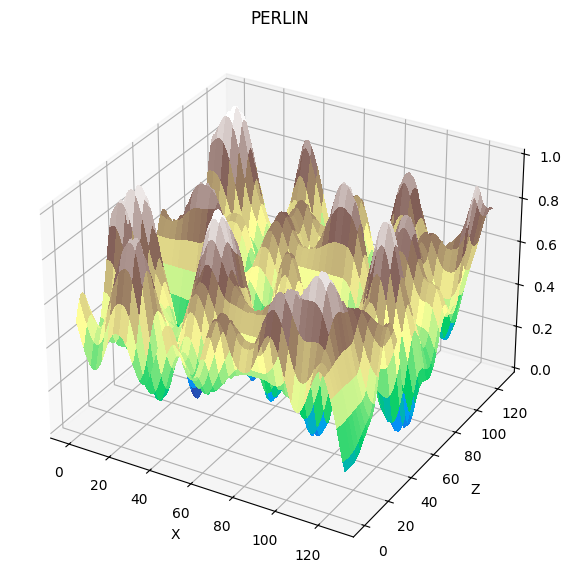

In [6]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

X, Y = np.meshgrid(
    range(terrain["width"]),
    range(terrain["height"])
)

ax.plot_surface(X, Y, hm,
    cmap=render_cfg.get("cmap", "terrain"),
    linewidth=0,
    antialiased=False
)

ax.set_title(noise_type.upper())
ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Y')
plt.show()